# Cost Quantification and Healthcare Impact Analysis

This notebook estimates the potential operational and financial impact
of care coordination gaps across Missouri counties and St. Louis ZIP/ZCTA
areas.

The goal is not to produce exact actuarial estimates, but to create a
reasonable healthcare analytics framework for estimating where avoidable
hospital use, readmission risk, and intervention opportunity may be greatest.

In [2]:
# Import core analytical libraries

import pandas as pd
import numpy as np
from pathlib import Path

In [3]:
# Define project folders

DATA_PROCESSED = Path("data/processed")
OUTPUTS = Path("outputs/charts")

# Create output folder if needed
OUTPUTS.mkdir(parents=True, exist_ok=True)

In [5]:
# Load final county-level dashboard dataset

county_df = pd.read_csv(
    "data/processed/missouri_county_final_dashboard_dataset.csv"
)

# Load final St. Louis ZIP-level vulnerability dataset

stl_zip_df = pd.read_csv(
    "data/processed/stl_zip_vulnerability_dataset.csv"
)

# Preview county data
county_df.head()

,county_name,county_fips,population,uninsured_rate,high_bp_rate,copd_rate,diabetes_rate,poor_mental_health,obesity_rate,fqhc_sites,...,resource_gap_score,care_coordination_gap_score,care_gap_rank,high_gap_flag,poverty_rate,median_household_income,acs_population,poverty_score,risk_tier,risk_tier_code
0,Pemiscot,29155,14613,13.1,40.1,11.3,17.9,20.5,44.9,1.0,...,92.605215,92.52,1.0,Yes,27.355036,40748,15232,100.000000,Critical Risk,4
1,Mississippi,29133,11822,13.2,40.0,10.5,14.1,21.2,47.7,1.0,...,90.859415,89.04,2.0,Yes,23.022798,46258,12079,80.881067,Critical Risk,4
2,Ozark,29153,8970,12.4,47.7,10.8,12.5,22.0,42.5,1.0,...,87.953177,86.65,3.0,Yes,21.688132,42329,8773,74.990954,Critical Risk,4
3,Dunklin,29069,27032,12.9,38.7,12.3,16.0,20.0,46.2,3.0,...,88.007547,84.40,4.0,Yes,21.446569,47368,27795,73.924891,Critical Risk,4
4,Howell,29091,40735,10.8,40.7,9.9,14.9,21.0,36.8,2.0,...,94.694489,79.10,5.0,Yes,21.388868,49814,40168,73.670246,Critical Risk,4


## Step 1 — Define Cost Assumptions

This section defines conservative assumptions used to estimate potential
avoidable healthcare burden.

The cost estimates are intended as directional planning estimates rather
than exact financial forecasts.

In [6]:
# Define cost assumptions for impact estimation
# These are planning assumptions, not exact actuarial values

AVG_READMISSION_COST = 15200

# Estimated annual hospitalization exposure rate among high-risk populations
# 8% is a conservative planning assumption for high-risk chronic/SDOH populations
HIGH_RISK_HOSPITALIZATION_RATE = 0.08

# Estimated share of hospitalizations that may be avoidable or reducible
# through improved care coordination
AVOIDABLE_SHARE = 0.15

# Estimated intervention effectiveness scenario
# Assumes care coordination could reduce avoidable events by 20%
INTERVENTION_REDUCTION = 0.20

## Step 2 — County-Level High-Risk Population Estimation

This section estimates the number of residents potentially exposed to
elevated care coordination burden by applying each county's care gap
score to its population.

This creates a comparable county-level opportunity measure.

In [7]:
# Estimate high-risk population exposure
# Care gap score is scaled from 0 to 100, then applied to county population

county_df["estimated_high_risk_population"] = (
    county_df["population"] *
    (county_df["care_coordination_gap_score"] / 100)
)

# Round for cleaner reporting
county_df["estimated_high_risk_population"] = (
    county_df["estimated_high_risk_population"]
    .round(0)
)

In [8]:
# Estimate annual hospitalization exposure among high-risk residents

county_df["estimated_high_risk_hospitalizations"] = (
    county_df["estimated_high_risk_population"] *
    HIGH_RISK_HOSPITALIZATION_RATE
)

county_df["estimated_high_risk_hospitalizations"] = (
    county_df["estimated_high_risk_hospitalizations"]
    .round(0)
)

In [9]:
# Estimate potentially avoidable hospitalizations

county_df["estimated_avoidable_hospitalizations"] = (
    county_df["estimated_high_risk_hospitalizations"] *
    AVOIDABLE_SHARE
)

county_df["estimated_avoidable_hospitalizations"] = (
    county_df["estimated_avoidable_hospitalizations"]
    .round(0)
)

In [10]:
# Estimate annual avoidable cost burden

county_df["estimated_avoidable_cost"] = (
    county_df["estimated_avoidable_hospitalizations"] *
    AVG_READMISSION_COST
)

county_df["estimated_avoidable_cost"] = (
    county_df["estimated_avoidable_cost"]
    .round(0)
)

In [11]:
# Estimate potential savings under care coordination intervention scenario

county_df["estimated_potential_savings"] = (
    county_df["estimated_avoidable_cost"] *
    INTERVENTION_REDUCTION
)

county_df["estimated_potential_savings"] = (
    county_df["estimated_potential_savings"]
    .round(0)
)

In [12]:
# Display counties with highest estimated avoidable cost burden

county_df[[
    "county_name",
    "population",
    "risk_tier",
    "care_coordination_gap_score",
    "estimated_high_risk_population",
    "estimated_avoidable_hospitalizations",
    "estimated_avoidable_cost",
    "estimated_potential_savings"
]].sort_values(
    "estimated_avoidable_cost",
    ascending=False
).head(20)

,county_name,population,risk_tier,care_coordination_gap_score,estimated_high_risk_population,estimated_avoidable_hospitalizations,estimated_avoidable_cost,estimated_potential_savings
80,Saint Louis,987059,Moderate Risk,56.91,561735.0,6741.0,102463200.0,20492640.0
108,Saint Louis,987059,Low Risk,49.05,484152.0,5810.0,88312000.0,17662400.0
51,Jackson,718560,High Risk,63.20,454130.0,5450.0,82840000.0,16568000.0
38,Saint Louis,281754,High Risk,66.42,187141.0,2246.0,34139200.0,6827840.0
114,St. Charles,416659,Low Risk,41.48,172830.0,2074.0,31524800.0,6304960.0
84,Greene,304611,Moderate Risk,55.90,170278.0,2043.0,31053600.0,6210720.0
70,Saint Louis,281754,Moderate Risk,58.57,165023.0,1980.0,30096000.0,6019200.0
106,Clay,259772,Low Risk,49.83,129444.0,1553.0,23605600.0,4721120.0
98,Jefferson,231230,Low Risk,52.09,120448.0,1445.0,21964000.0,4392800.0
101,Boone,189463,Low Risk,51.18,96967.0,1164.0,17692800.0,3538560.0


## Step 3 — Visualizing Estimated Healthcare Burden

This section visualizes estimated avoidable healthcare burden and
potential intervention opportunity across Missouri counties.

The visualizations support operational prioritization and population
health planning.

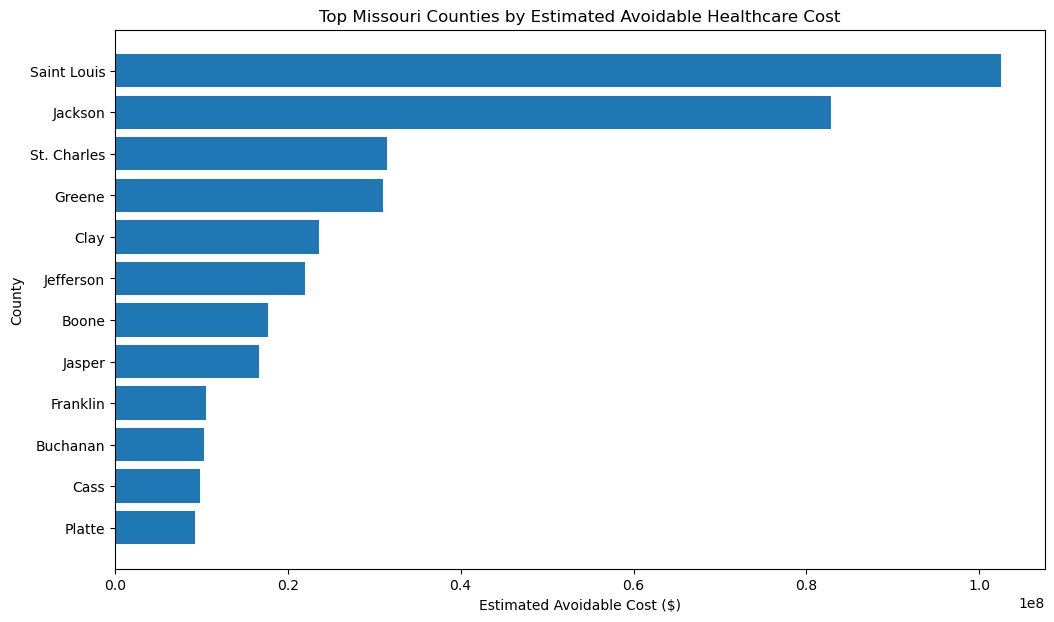

In [13]:
# Create bar chart of highest estimated avoidable cost counties

import matplotlib.pyplot as plt

# Select top counties
top_cost = county_df.sort_values(
    "estimated_avoidable_cost",
    ascending=False
).head(15)

# Create chart
plt.figure(figsize=(12, 7))

plt.barh(
    top_cost["county_name"],
    top_cost["estimated_avoidable_cost"]
)

# Labels and title
plt.xlabel("Estimated Avoidable Cost ($)")
plt.ylabel("County")
plt.title(
    "Top Missouri Counties by Estimated Avoidable Healthcare Cost"
)

# Reverse order for readability
plt.gca().invert_yaxis()

# Save chart
plt.savefig(
    "outputs/charts/top_county_avoidable_cost.png",
    dpi=300,
    bbox_inches="tight"
)

# Show chart
plt.show()

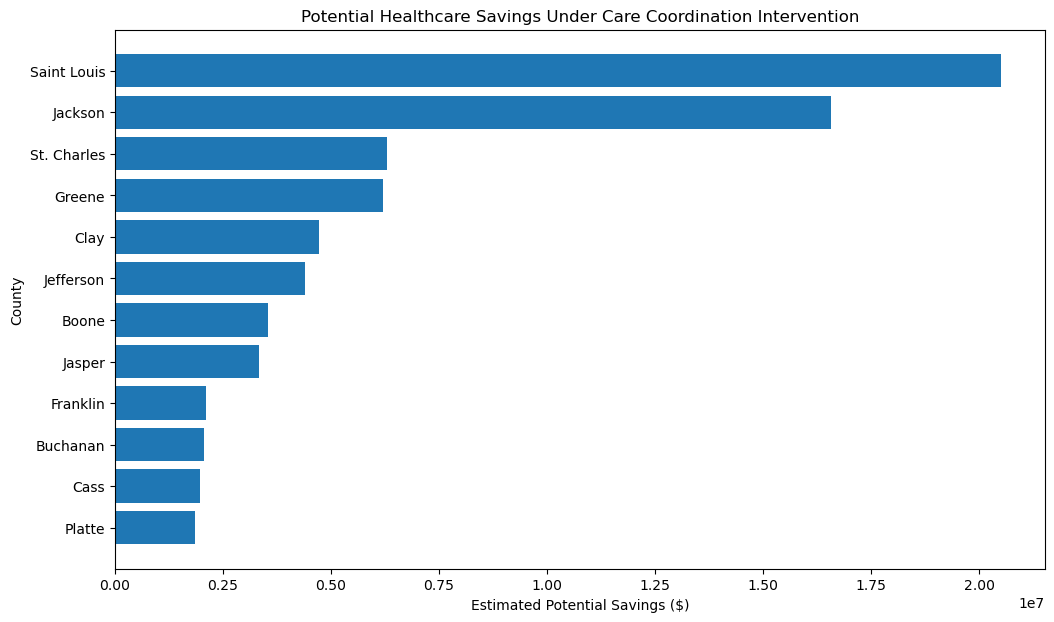

In [14]:
# Create chart for estimated potential intervention savings

top_savings = county_df.sort_values(
    "estimated_potential_savings",
    ascending=False
).head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_savings["county_name"],
    top_savings["estimated_potential_savings"]
)

# Labels and title
plt.xlabel("Estimated Potential Savings ($)")
plt.ylabel("County")

plt.title(
    "Potential Healthcare Savings Under Care Coordination Intervention"
)

# Reverse order
plt.gca().invert_yaxis()

# Save chart
plt.savefig(
    "outputs/charts/potential_intervention_savings.png",
    dpi=300,
    bbox_inches="tight"
)

# Show chart
plt.show()

## Step 4 — St. Louis ZIP-Level Cost Quantification

This section applies the same impact estimation framework to localized
St. Louis ZIP/ZCTA areas.

ZIP-level estimation supports neighborhood-level operational targeting
and more localized population health intervention planning.

In [15]:
# Estimate high-risk population exposure for St. Louis ZIP areas

stl_zip_df["estimated_high_risk_population"] = (
    stl_zip_df["population"] *
    (
        stl_zip_df["zip_sdoh_vulnerability_index"] / 100
    )
)

stl_zip_df["estimated_high_risk_population"] = (
    stl_zip_df["estimated_high_risk_population"]
    .round(0)
)

In [16]:
# Estimate annual high-risk hospitalization exposure

stl_zip_df["estimated_high_risk_hospitalizations"] = (
    stl_zip_df["estimated_high_risk_population"] *
    HIGH_RISK_HOSPITALIZATION_RATE
)

stl_zip_df["estimated_high_risk_hospitalizations"] = (
    stl_zip_df["estimated_high_risk_hospitalizations"]
    .round(0)
)

In [17]:
# Estimate avoidable hospitalization burden

stl_zip_df["estimated_avoidable_hospitalizations"] = (
    stl_zip_df["estimated_high_risk_hospitalizations"] *
    AVOIDABLE_SHARE
)

stl_zip_df["estimated_avoidable_hospitalizations"] = (
    stl_zip_df["estimated_avoidable_hospitalizations"]
    .round(0)
)

In [18]:
# Estimate avoidable healthcare cost burden

stl_zip_df["estimated_avoidable_cost"] = (
    stl_zip_df["estimated_avoidable_hospitalizations"] *
    AVG_READMISSION_COST
)

stl_zip_df["estimated_avoidable_cost"] = (
    stl_zip_df["estimated_avoidable_cost"]
    .round(0)
)

In [20]:
# Estimate potential savings from care coordination intervention

stl_zip_df["estimated_potential_savings"] = (
    stl_zip_df["estimated_avoidable_cost"] *
    INTERVENTION_REDUCTION
)

stl_zip_df["estimated_potential_savings"] = (
    stl_zip_df["estimated_potential_savings"]
    .round(0)
)

In [21]:
# Display highest-burden St. Louis ZIP areas

stl_zip_df[[
    "zcta",
    "zip_sdoh_vulnerability_index",
    "population",
    "estimated_high_risk_population",
    "estimated_avoidable_cost",
    "estimated_potential_savings"
]].sort_values(
    "estimated_avoidable_cost",
    ascending=False
).head(15)

,zcta,zip_sdoh_vulnerability_index,population,estimated_high_risk_population,estimated_avoidable_cost,estimated_potential_savings
6,63136,86.190476,41314.0,35609.0,6490400.0,1298080.0
20,63116,52.857143,42470.0,22448.0,4088800.0,817760.0
16,63114,64.444444,33703.0,21720.0,3967200.0,793440.0
23,63123,41.904762,49826.0,20879.0,3800000.0,760000.0
26,63129,37.936508,51356.0,19483.0,3556800.0,711360.0
19,63125,56.031746,32701.0,18323.0,3344000.0,668800.0
12,63121,74.126984,24571.0,18214.0,3328800.0,665760.0
7,63137,83.333333,19690.0,16408.0,2994400.0,598880.0
17,63118,62.222222,25645.0,15957.0,2918400.0,583680.0
11,63111,77.460317,19093.0,14789.0,2690400.0,538080.0


### Interpretation

The ZIP-level cost quantification analysis identifies localized
neighborhood areas where elevated healthcare vulnerability and
population concentration may combine to create higher estimated
operational and financial burden.

These ZIP regions may represent strategic targets for localized
care coordination programs, community health outreach, and SDOH-focused
interventions.

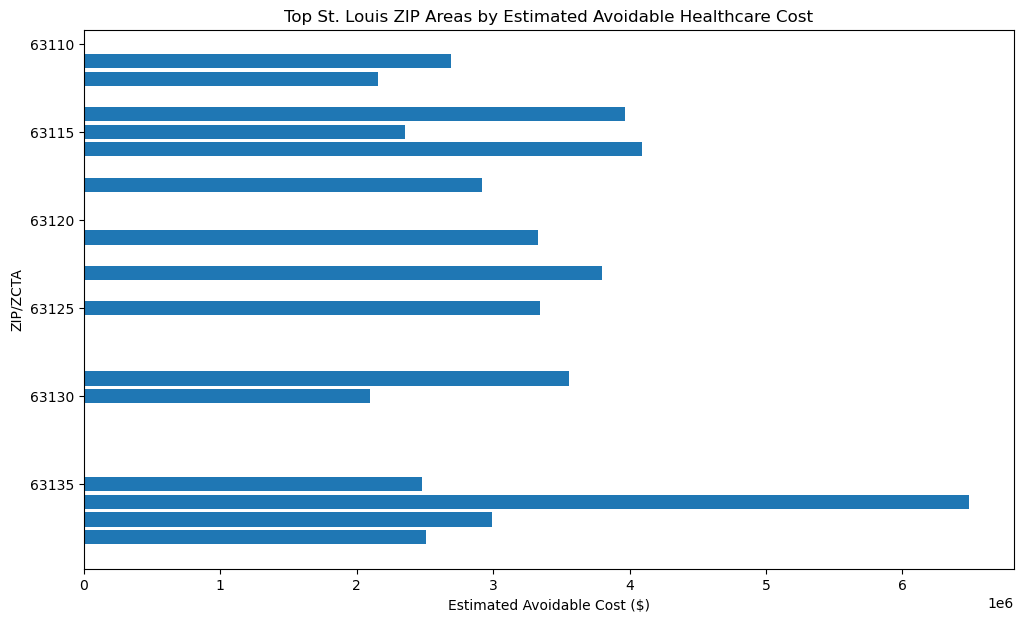

In [22]:
# Visualize highest-burden ZIP areas

top_zip_cost = stl_zip_df.sort_values(
    "estimated_avoidable_cost",
    ascending=False
).head(15)

plt.figure(figsize=(12, 7))

plt.barh(
    top_zip_cost["zcta"],
    top_zip_cost["estimated_avoidable_cost"]
)

# Labels and title
plt.xlabel("Estimated Avoidable Cost ($)")
plt.ylabel("ZIP/ZCTA")

plt.title(
    "Top St. Louis ZIP Areas by Estimated Avoidable Healthcare Cost"
)

# Reverse order
plt.gca().invert_yaxis()

# Save figure
plt.savefig(
    "outputs/charts/top_stl_zip_cost.png",
    dpi=300,
    bbox_inches="tight"
)

# Show chart
plt.show()

### Interpretation

The ZIP-level avoidable healthcare cost estimates demonstrate that
healthcare burden within the St. Louis region is highly localized.

Several ZIP areas demonstrate disproportionately elevated estimated
avoidable healthcare exposure, suggesting concentrated need for
community-level intervention, care coordination outreach, and SDOH-focused
population health programs.

ZIP-level operational analysis may support more targeted intervention
planning than broader county-level approaches alone.

## Step 5 — Final Dataset Preparation for Power BI

This section prepares finalized analytical datasets for interactive
dashboard visualization and executive reporting within Power BI.

In [23]:
# Select final county dashboard variables

county_dashboard = county_df[[
    "county_name",
    "county_fips",
    "population",
    "risk_tier",
    "care_coordination_gap_score",
    "sdoh_vulnerability_index",
    "poverty_rate",
    "uninsured_rate",
    "poor_mental_health",
    "diabetes_rate",
    "high_bp_rate",
    "obesity_rate",
    "copd_rate",
    "fqhc_per_10000",
    "estimated_high_risk_population",
    "estimated_avoidable_hospitalizations",
    "estimated_avoidable_cost",
    "estimated_potential_savings"
]].copy()

# Preview dataset
county_dashboard.head()

,county_name,county_fips,population,risk_tier,care_coordination_gap_score,sdoh_vulnerability_index,poverty_rate,uninsured_rate,poor_mental_health,diabetes_rate,high_bp_rate,obesity_rate,copd_rate,fqhc_per_10000,estimated_high_risk_population,estimated_avoidable_hospitalizations,estimated_avoidable_cost,estimated_potential_savings
0,Pemiscot,29155,14613,Critical Risk,92.52,92.48,27.355036,13.1,20.5,17.9,40.1,44.9,11.3,0.68,13520.0,162.0,2462400.0,492480.0
1,Mississippi,29133,11822,Critical Risk,89.04,88.27,23.022798,13.2,21.2,14.1,40.0,47.7,10.5,0.85,10526.0,126.0,1915200.0,383040.0
2,Ozark,29153,8970,Critical Risk,86.65,86.10,21.688132,12.4,22.0,12.5,47.7,42.5,10.8,1.11,7773.0,93.0,1413600.0,282720.0
3,Dunklin,29069,27032,Critical Risk,84.40,82.85,21.446569,12.9,20.0,16.0,38.7,46.2,12.3,1.11,22815.0,274.0,4164800.0,832960.0
4,Howell,29091,40735,Critical Risk,79.10,72.42,21.388868,10.8,21.0,14.9,40.7,36.8,9.9,0.49,32221.0,387.0,5882400.0,1176480.0


In [24]:
# Select final ZIP dashboard variables

zip_dashboard = stl_zip_df[[
    "zcta",
    "population",
    "zip_sdoh_vulnerability_index",
    "poverty_rate",
    "median_household_income",
    "uninsured_rate",
    "poor_mental_health",
    "diabetes_rate",
    "high_bp_rate",
    "obesity_rate",
    "copd_rate",
    "estimated_high_risk_population",
    "estimated_avoidable_hospitalizations",
    "estimated_avoidable_cost",
    "estimated_potential_savings"
]].copy()

# Preview dataset
zip_dashboard.head()

,zcta,population,zip_sdoh_vulnerability_index,poverty_rate,median_household_income,uninsured_rate,poor_mental_health,diabetes_rate,high_bp_rate,obesity_rate,copd_rate,estimated_high_risk_population,estimated_avoidable_hospitalizations,estimated_avoidable_cost,estimated_potential_savings
0,63120,7227.0,96.666667,30.165826,34097.0,15.6,22.5,24.1,53.0,49.4,13.4,6986.0,84.0,1276800.0,255360.0
1,63106,7742.0,93.492063,40.950521,21475.0,13.8,23.0,22.1,50.0,49.8,12.2,7238.0,87.0,1322400.0,264480.0
2,63115,14252.0,90.793651,31.338003,31898.0,12.8,20.5,24.1,53.9,48.5,12.2,12940.0,155.0,2356000.0,471200.0
3,63107,9082.0,88.412698,21.521377,40522.0,13.3,21.0,23.8,53.1,48.6,12.6,8030.0,96.0,1459200.0,291840.0
4,63113,11610.0,87.777778,29.440433,38647.0,12.8,20.6,23.4,52.6,47.8,12.3,10191.0,122.0,1854400.0,370880.0


In [26]:
# Save Power BI county dataset

county_dashboard.to_csv(
    "data/processed/powerbi_county_dashboard_dataset.csv",
    index=False
)

county_dashboard.to_excel(
    "data/processed/powerbi_county_dashboard_dataset.xlsx",
    index=False
)

print("County Power BI dataset saved.")

County Power BI dataset saved.


In [27]:
# Save Power BI ZIP dataset

zip_dashboard.to_csv(
    "data/processed/powerbi_zip_dashboard_dataset.csv",
    index=False
)

zip_dashboard.to_excel(
    "data/processed/powerbi_zip_dashboard_dataset.xlsx",
    index=False
)

print("ZIP Power BI dataset saved.")

ZIP Power BI dataset saved.


In [28]:
# Generate high-level project summary metrics

summary_metrics = pd.DataFrame({

    "metric": [
        "Total Missouri Counties",
        "Total St. Louis ZIP Areas",
        "Highest County Gap Score",
        "Highest ZIP Vulnerability Score",
        "Total Estimated Avoidable County Cost",
        "Total Estimated County Savings Opportunity"
    ],

    "value": [
        county_dashboard.shape[0],
        zip_dashboard.shape[0],
        county_dashboard["care_coordination_gap_score"].max(),
        zip_dashboard["zip_sdoh_vulnerability_index"].max(),
        county_dashboard["estimated_avoidable_cost"].sum(),
        county_dashboard["estimated_potential_savings"].sum()
    ]
})

# Preview summary metrics
summary_metrics

,metric,value
0,Total Missouri Counties,1.170000e+02
1,Total St. Louis ZIP Areas,4.500000e+01
2,Highest County Gap Score,9.252000e+01
3,Highest ZIP Vulnerability Score,9.666667e+01
4,Total Estimated Avoidable County Cost,7.748504e+08
5,Total Estimated County Savings Opportunity,1.549701e+08


In [29]:
# Save executive summary metrics

summary_metrics.to_csv(
    "data/processed/project_summary_metrics.csv",
    index=False
)

summary_metrics.to_excel(
    "data/processed/project_summary_metrics.xlsx",
    index=False
)

print("Project summary metrics saved.")

Project summary metrics saved.


# Project Completion Summary

This project developed a multi-level healthcare vulnerability and care
coordination gap analytics framework for Missouri and the St. Louis region.

The framework integrated:
- CDC PLACES health indicators
- ACS socioeconomic indicators
- FQHC healthcare access indicators
- geographic analysis
- vulnerability scoring
- operational risk stratification
- healthcare impact estimation

The project produced:
- county-level analytical datasets
- ZIP-level analytical datasets
- geographic visualizations
- operational risk stratification
- estimated avoidable healthcare burden metrics
- Power BI-ready dashboard datasets

This framework may support future work in:
- population health analytics
- SDOH intervention targeting
- healthcare operations planning
- care coordination strategy
- community health outreach
- ConnexiCare platform development